# RAG Evaluation Research

**Research Question:** Can better RAG techniques improve answer quality even with suboptimal data quality?

We compare three RAG approaches against the same knowledge base and evaluate them with RAGAS metrics:
1. **Simple RAG** — Direct pgvector similarity search + OpenAI
2. **LangChain RAG** — LangChain with pgvector retriever
3. **Haystack RAG** — Haystack with Elasticsearch (BM25 + semantic)

---

## 1. Setup & Configuration

In [1]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

from dotenv import load_dotenv
load_dotenv()

DB_URL = os.getenv("DB_URL")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
EMBEDDING_MODEL = os.getenv("OPENAI_EMBEDDING_MODEL", "text-embedding-3-small")
COLLECTION_NAME = os.getenv("COLLECTION_NAME", "2bad0dc7-35d7-48fc-bd2c-7b42ccb2189f")
ES_URL = "http://localhost:9200"

TOP_K = 5
LLM_MODEL = "gpt-4o-mini"

print(f"DB_URL: {DB_URL[:30]}...")
print(f"Embedding model: {EMBEDDING_MODEL}")
print(f"Collection: {COLLECTION_NAME}")
print(f"LLM: {LLM_MODEL}")
print(f"Top-K: {TOP_K}")

DB_URL: postgresql://postgres:9mgl0n5c...
Embedding model: text-embedding-3-small
Collection: 2bad0dc7-35d7-48fc-bd2c-7b42ccb2189f
LLM: gpt-4o-mini
Top-K: 5


In [2]:
from openai import OpenAI
import psycopg2
import pandas as pd
import numpy as np

openai_client = OpenAI(api_key=OPENAI_API_KEY)

# Verify database connection
conn = psycopg2.connect(DB_URL, connect_timeout=10)
cur = conn.cursor()
cur.execute(
    "SELECT COUNT(*) FROM document_chunk WHERE collection_name = %s",
    (COLLECTION_NAME,)
)
chunk_count = cur.fetchone()[0]
print(f"Connected to database. Found {chunk_count} chunks in collection.")
cur.close()
conn.close()

Connected to database. Found 3806 chunks in collection.


## 2. Data Exploration & Quality Assessment

In [3]:
conn = psycopg2.connect(DB_URL, connect_timeout=10)
cur = conn.cursor()
cur.execute(
    "SELECT id, text, vmetadata FROM document_chunk WHERE collection_name = %s",
    (COLLECTION_NAME,)
)
rows = cur.fetchall()
cur.close()
conn.close()

chunks_df = pd.DataFrame(rows, columns=["id", "text", "metadata"])
chunks_df["char_len"] = chunks_df["text"].str.len()
chunks_df["word_count"] = chunks_df["text"].str.split().str.len()

print(f"Total chunks: {len(chunks_df)}")
print(f"\nCharacter length statistics:")
print(chunks_df["char_len"].describe().to_string())
print(f"\nWord count statistics:")
print(chunks_df["word_count"].describe().to_string())

Total chunks: 3806

Character length statistics:
count    3806.000000
mean     3066.183395
std       714.988582
min       396.000000
25%      2522.000000
50%      3061.000000
75%      3637.000000
max      5456.000000

Word count statistics:
count    3806.000000
mean      464.982396
std       102.159626
min        57.000000
25%       390.000000
50%       468.000000
75%       543.000000
max       682.000000


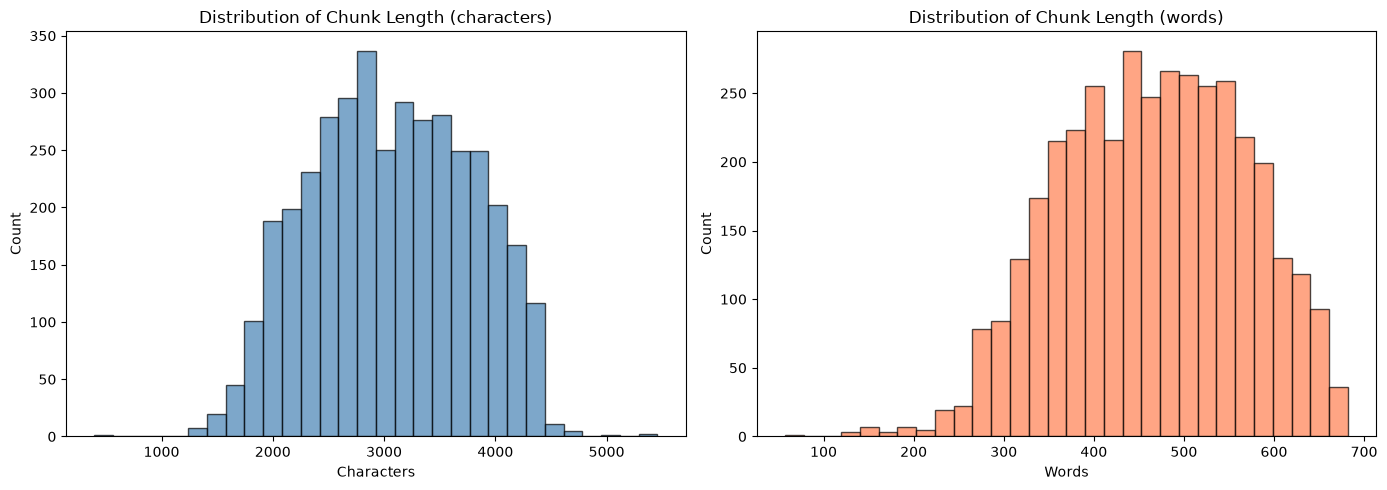

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(chunks_df["char_len"], bins=30, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].set_title("Distribution of Chunk Length (characters)")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Count")

axes[1].hist(chunks_df["word_count"], bins=30, edgecolor="black", alpha=0.7, color="coral")
axes[1].set_title("Distribution of Chunk Length (words)")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [5]:
print("=" * 80)
print("SAMPLE CHUNKS (first 5)")
print("=" * 80)
for i, row in chunks_df.head(5).iterrows():
    print(f"\n--- Chunk {i} ({row['char_len']} chars, {row['word_count']} words) ---")
    print(row["text"][:500])
    print()

SAMPLE CHUNKS (first 5)

--- Chunk 0 (3632 chars, 536 words) ---
SAUDI ARAMCO — COMPLETE KNOWLEDGE BASE
Generated from: Official Annual Reports (2017-2026), Quarterly Reports, Press Releases, and Website
Coverage: Financial results, production data, sustainability, operations, careers, leadership

SOURCES INCLUDED:
  - Annual Reports: 2019, 2020, 2021, 2022, 2023, 2024, 2025
  - Full Financials: 2018-2025 (full-year)
  - Quarterly Interim Reports: Q1/H1/Q3 2020-2026
  - Press Releases: Q1 2019 – Q1 2026
  - Non-IFRS Reconciliations: 2019-2024
  - Website: Abo


--- Chunk 1 (4071 chars, 611 words) ---
.
At Aramco, we are proactively doing our part to reliably, and ever-more-sustainably, provide the energy products that enable people to seize opportunities that can transform our world.
Where we're going
We're explorers at heart. That drive to reach the next frontier or solve the next great problem has allowed us to build one of the world’s most important energy and chemicals enterprises.

## 3. Golden Test Set Generation

We sample diverse chunks and use GPT-4o-mini to generate 10 question-answer pairs as our ground truth evaluation set.

In [6]:
# Sample diverse chunks — pick chunks with substantial content
substantial_chunks = chunks_df[chunks_df["word_count"] >= 30].copy()
if len(substantial_chunks) < 20:
    substantial_chunks = chunks_df.nlargest(20, "word_count")

sampled = substantial_chunks.sample(n=min(20, len(substantial_chunks)), random_state=42)
print(f"Sampled {len(sampled)} chunks for Q&A generation")

# Build context for GPT
chunks_text = ""
for i, (_, row) in enumerate(sampled.iterrows()):
    chunks_text += f"\n[CHUNK {i+1}]\n{row['text']}\n"

prompt = f"""Based on the following document chunks from a knowledge base, generate exactly 10 question-answer pairs.

Requirements:
- Questions should be diverse and cover different chunks
- Questions should be answerable from the provided chunks
- Answers should be concise (1-3 sentences) and factually grounded in the chunks
- Include the chunk number(s) used as source

Return your response as a JSON array with this format:
[
  {{
    "question": "...",
    "ground_truth": "...",
    "source_chunks": [1, 2]
  }}
]

Document chunks:
{chunks_text}

Return ONLY the JSON array, no other text."""

response = openai_client.chat.completions.create(
    model=LLM_MODEL,
    messages=[{"role": "user", "content": prompt}],
    temperature=0.3,
)

raw = response.choices[0].message.content.strip()
if raw.startswith("```"):
    raw = raw.split("\n", 1)[1].rsplit("```", 1)[0]

golden_set = json.loads(raw)
golden_df = pd.DataFrame(golden_set)
print(f"Generated {len(golden_df)} Q&A pairs\n")
for i, row in golden_df.iterrows():
    print(f"Q{i+1}: {row['question']}")
    print(f"A{i+1}: {row['ground_truth']}")
    print()

Sampled 20 chunks for Q&A generation
Generated 10 Q&A pairs

Q1: What was the net cash provided by operating activities for the year?
A1: The net cash provided by operating activities was 416,529 million SAR.

Q2: What is the expected processing capacity of the Tanajib Gas Plant once completed?
A2: The Tanajib Gas Plant is expected to add 2.5 bscfd of additional processing capacity.

Q3: What percentage ownership does Saudi Aramco have in the Gulf Petrochemical Industries Company?
A3: Saudi Aramco has an 11.7% ownership in the Gulf Petrochemical Industries Company.

Q4: What is the purpose of the Nomination Committee in relation to the Board of Directors?
A4: The Nomination Committee considers diversity and assesses candidates' skills and experience when reviewing the Board's composition.

Q5: What is the estimated gas production capacity from the Jafurah unconventional gas field by 2030?
A5: The estimated gas production capacity from the Jafurah unconventional gas field is expected to

## 4. Simple RAG (Direct pgvector + OpenAI)

The baseline approach: embed the query with OpenAI, run cosine similarity search against pgvector, generate answer.

In [7]:
def embed_query(query: str) -> list[float]:
    response = openai_client.embeddings.create(
        input=[query], model=EMBEDDING_MODEL
    )
    return response.data[0].embedding


def simple_retrieve(query: str, top_k: int = TOP_K) -> list[str]:
    vector = embed_query(query)
    vector_str = "[" + ",".join(str(x) for x in vector) + "]"

    conn = psycopg2.connect(DB_URL, connect_timeout=10)
    cur = conn.cursor()
    cur.execute(
        """
        SELECT text, 1 - (vector <=> %s::vector) AS similarity
        FROM document_chunk
        WHERE collection_name = %s
        ORDER BY vector <=> %s::vector
        LIMIT %s
        """,
        (vector_str, COLLECTION_NAME, vector_str, top_k),
    )
    rows = cur.fetchall()
    cur.close()
    conn.close()
    return [text for text, _ in rows]


def generate_answer(query: str, contexts: list[str]) -> str:
    context_text = "\n\n".join(contexts)
    response = openai_client.chat.completions.create(
        model=LLM_MODEL,
        messages=[
            {
                "role": "system",
                "content": "Answer the question based only on the provided context. "
                "If the context doesn't contain enough information, say so.",
            },
            {
                "role": "user",
                "content": f"Context:\n{context_text}\n\nQuestion: {query}",
            },
        ],
        temperature=0,
    )
    return response.choices[0].message.content

In [8]:
simple_results = []

for i, row in golden_df.iterrows():
    question = row["question"]
    print(f"Q{i+1}: {question}")

    contexts = simple_retrieve(question)
    answer = generate_answer(question, contexts)

    simple_results.append({
        "question": question,
        "ground_truth": row["ground_truth"],
        "contexts": contexts,
        "answer": answer,
    })
    print(f"A{i+1}: {answer[:200]}...\n")

print(f"Simple RAG: {len(simple_results)} questions answered.")

Q1: What was the net cash provided by operating activities for the year?
A1: The provided context does not contain information regarding the net cash provided by operating activities for the year....

Q2: What is the expected processing capacity of the Tanajib Gas Plant once completed?
A2: The context does not provide information about the expected processing capacity of the Tanajib Gas Plant once completed....

Q3: What percentage ownership does Saudi Aramco have in the Gulf Petrochemical Industries Company?
A3: The context does not provide information about the percentage ownership of Saudi Aramco in the Gulf Petrochemical Industries Company....

Q4: What is the purpose of the Nomination Committee in relation to the Board of Directors?
A4: The provided context does not contain any information regarding the purpose of the Nomination Committee in relation to the Board of Directors....

Q5: What is the estimated gas production capacity from the Jafurah unconventional gas field by 2030?


## 5. LangChain RAG (pgvector)

Uses LangChain's PGVector integration with LCEL chains.

In [9]:
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough

# LangChain pgvector uses psycopg3 — convert URL format
LC_DB_URL = DB_URL.replace("postgresql://", "postgresql+psycopg://")

lc_embeddings = OpenAIEmbeddings(
    model=EMBEDDING_MODEL, api_key=OPENAI_API_KEY
)
lc_llm = ChatOpenAI(model=LLM_MODEL, api_key=OPENAI_API_KEY, temperature=0)

In [10]:
from langchain_postgres import PGVector

lc_vectorstore = PGVector(
    embeddings=lc_embeddings,
    collection_name=COLLECTION_NAME,
    connection=LC_DB_URL,
    use_jsonb=True,
)

lc_retriever = lc_vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": TOP_K},
)

# Test retrieval
test_docs = lc_retriever.invoke(golden_df.iloc[0]["question"])
# print(f"LangChain retriever working. Got {len(test_docs)} docs.")
# print(f"First doc preview: {test_docs[0].page_content[:200]}...")

In [11]:
lc_prompt = ChatPromptTemplate.from_template(
    "Answer the question based only on the provided context. "
    "If the context doesn't contain enough information, say so.\n\n"
    "Context:\n{context}\n\nQuestion: {question}"
)


def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


langchain_results = []

for i, row in golden_df.iterrows():
    question = row["question"]
    print(f"Q{i+1}: {question}")

    docs = lc_retriever.invoke(question)
    contexts = [doc.page_content for doc in docs]
    context_text = format_docs(docs)

    chain = lc_prompt | lc_llm | StrOutputParser()
    answer = chain.invoke({"context": context_text, "question": question})

    langchain_results.append({
        "question": question,
        "ground_truth": row["ground_truth"],
        "contexts": contexts,
        "answer": answer,
    })
    print(f"A{i+1}: {answer[:200]}...\n")

print(f"LangChain RAG: {len(langchain_results)} questions answered.")

Q1: What was the net cash provided by operating activities for the year?
A1: The context does not contain enough information to answer the question about the net cash provided by operating activities for the year....

Q2: What is the expected processing capacity of the Tanajib Gas Plant once completed?
A2: The context does not provide information about the expected processing capacity of the Tanajib Gas Plant once completed....

Q3: What percentage ownership does Saudi Aramco have in the Gulf Petrochemical Industries Company?
A3: The context does not contain enough information to answer the question about the percentage ownership of Saudi Aramco in the Gulf Petrochemical Industries Company....

Q4: What is the purpose of the Nomination Committee in relation to the Board of Directors?
A4: The context does not provide enough information to answer the question about the purpose of the Nomination Committee in relation to the Board of Directors....

Q5: What is the estimated gas production 

## 6. Haystack RAG with Elasticsearch

Loads the same chunks into Elasticsearch and runs both semantic (embedding) and BM25 (keyword) retrieval.

**Prerequisites:** Run `docker compose up -d` to start Elasticsearch.

In [12]:
import requests

try:
    r = requests.get(ES_URL, timeout=5)
    print(f"Elasticsearch is running: {r.json()['version']['number']}")
except Exception as e:
    print(f"Elasticsearch not reachable at {ES_URL}: {e}")
    print("Run: docker compose up -d")

Elasticsearch is running: 8.15.0


In [13]:
from haystack import Document, Pipeline
from haystack.components.embedders import OpenAIDocumentEmbedder, OpenAITextEmbedder
from haystack.utils import Secret
from haystack_integrations.document_stores.elasticsearch import ElasticsearchDocumentStore
from haystack_integrations.components.retrievers.elasticsearch import (
    ElasticsearchEmbeddingRetriever,
    ElasticsearchBM25Retriever,
)

# Create document store
es_document_store = ElasticsearchDocumentStore(
    hosts=ES_URL,
    index="rag-eval-chunks",
    embedding_similarity_function="cosine",
)

# Convert chunks to Haystack Documents
haystack_docs = []
for _, row in chunks_df.iterrows():
    meta = row["metadata"] if isinstance(row["metadata"], dict) else {}
    haystack_docs.append(
        Document(content=row["text"], meta=meta)
    )

print(f"Prepared {len(haystack_docs)} documents for indexing")

# Embed documents
doc_embedder = OpenAIDocumentEmbedder(
    model=EMBEDDING_MODEL, api_key=Secret.from_token(OPENAI_API_KEY)
)
docs_with_embeddings = doc_embedder.run(documents=haystack_docs)

# Write to Elasticsearch
es_document_store.write_documents(docs_with_embeddings["documents"])
print(f"Indexed {es_document_store.count_documents()} documents in Elasticsearch")

Prepared 3806 documents for indexing


Calculating embeddings: 58it [00:37,  1.56it/s]


KeyboardInterrupt: 

In [ ]:
from haystack.components.builders import ChatPromptBuilder, AnswerBuilder
from haystack.components.generators.chat import OpenAIChatGenerator
from haystack.dataclasses import ChatMessage

# -- Semantic (embedding) retrieval pipeline --
hs_text_embedder = OpenAITextEmbedder(model=EMBEDDING_MODEL, api_key=Secret.from_token(OPENAI_API_KEY))
hs_embedding_retriever = ElasticsearchEmbeddingRetriever(
    document_store=es_document_store, top_k=TOP_K
)

hs_template = [
    ChatMessage.from_user(
        "Answer the question based only on the provided context. "
        "If the context doesn't contain enough information, say so.\n\n"
        "Context:\n{% for doc in documents %}{{ doc.content }}\n\n{% endfor %}"
        "Question: {{ question }}"
    )
]

hs_semantic_pipeline = Pipeline()
hs_semantic_pipeline.add_component("text_embedder", hs_text_embedder)
hs_semantic_pipeline.add_component("retriever", hs_embedding_retriever)
hs_semantic_pipeline.add_component("prompt_builder", ChatPromptBuilder(template=hs_template))
hs_semantic_pipeline.add_component("llm", OpenAIChatGenerator(model=LLM_MODEL, api_key=Secret.from_token(OPENAI_API_KEY)))

hs_semantic_pipeline.connect("text_embedder.embedding", "retriever.query_embedding")
hs_semantic_pipeline.connect("retriever.documents", "prompt_builder.documents")
hs_semantic_pipeline.connect("prompt_builder.prompt", "llm.messages")

print("Haystack semantic pipeline built.")

In [ ]:
# -- BM25 (keyword) retrieval pipeline --
hs_bm25_retriever = ElasticsearchBM25Retriever(
    document_store=es_document_store, top_k=TOP_K
)

hs_bm25_pipeline = Pipeline()
hs_bm25_pipeline.add_component("retriever", hs_bm25_retriever)
hs_bm25_pipeline.add_component("prompt_builder", ChatPromptBuilder(template=hs_template))
hs_bm25_pipeline.add_component("llm", OpenAIChatGenerator(model=LLM_MODEL, api_key=Secret.from_token(OPENAI_API_KEY)))

hs_bm25_pipeline.connect("retriever.documents", "prompt_builder.documents")
hs_bm25_pipeline.connect("prompt_builder.prompt", "llm.messages")

print("Haystack BM25 pipeline built.")

In [ ]:
haystack_semantic_results = []

for i, row in golden_df.iterrows():
    question = row["question"]
    print(f"Q{i+1}: {question}")

    result = hs_semantic_pipeline.run({
        "text_embedder": {"text": question},
        "prompt_builder": {"question": question},
    })

    contexts = [doc.content for doc in result["retriever"]["documents"]]
    answer = result["llm"]["replies"][0].text

    haystack_semantic_results.append({
        "question": question,
        "ground_truth": row["ground_truth"],
        "contexts": contexts,
        "answer": answer,
    })
    print(f"A{i+1}: {answer[:200]}...\n")

print(f"Haystack Semantic RAG: {len(haystack_semantic_results)} questions answered.")

In [ ]:
haystack_bm25_results = []

for i, row in golden_df.iterrows():
    question = row["question"]
    print(f"Q{i+1}: {question}")

    result = hs_bm25_pipeline.run({
        "retriever": {"query": question},
        "prompt_builder": {"question": question},
    })

    contexts = [doc.content for doc in result["retriever"]["documents"]]
    answer = result["llm"]["replies"][0].text

    haystack_bm25_results.append({
        "question": question,
        "ground_truth": row["ground_truth"],
        "contexts": contexts,
        "answer": answer,
    })
    print(f"A{i+1}: {answer[:200]}...\n")

print(f"Haystack BM25 RAG: {len(haystack_bm25_results)} questions answered.")

## 7. RAGAS Evaluation

Evaluate all four RAG approaches using RAGAS metrics via the Haystack integration:
- **Faithfulness**: Is the answer grounded in the retrieved context?
- **Answer Relevancy**: Does the answer address the question?
- **Context Precision**: Are relevant chunks ranked higher?
- **Context Recall**: Do retrieved chunks cover the ground truth?

In [ ]:
from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision, ContextRecall
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI as LCChatOpenAI, OpenAIEmbeddings as LCOpenAIEmbeddings

evaluator_llm = LangchainLLMWrapper(LCChatOpenAI(model=LLM_MODEL, api_key=OPENAI_API_KEY))
evaluator_embeddings = LangchainEmbeddingsWrapper(LCOpenAIEmbeddings(model=EMBEDDING_MODEL, api_key=OPENAI_API_KEY))

metrics = [
    Faithfulness(llm=evaluator_llm),
    AnswerRelevancy(llm=evaluator_llm, embeddings=evaluator_embeddings),
    ContextPrecision(llm=evaluator_llm),
    ContextRecall(llm=evaluator_llm),
]

print(f"Initialized {len(metrics)} RAGAS metrics: {[m.__class__.__name__ for m in metrics]}")

In [ ]:
from ragas import EvaluationDataset, SingleTurnSample, evaluate


def build_eval_dataset(results: list[dict]) -> EvaluationDataset:
    samples = []
    for r in results:
        samples.append(
            SingleTurnSample(
                user_input=r["question"],
                response=r["answer"],
                retrieved_contexts=r["contexts"],
                reference=r["ground_truth"],
            )
        )
    return EvaluationDataset(samples=samples)


all_approaches = {
    "Simple RAG": simple_results,
    "LangChain RAG": langchain_results,
    "Haystack Semantic": haystack_semantic_results,
    "Haystack BM25": haystack_bm25_results,
}

evaluation_scores = {}

for name, results in all_approaches.items():
    print(f"\nEvaluating: {name}...")
    dataset = build_eval_dataset(results)
    eval_result = evaluate(
        dataset=dataset,
        metrics=metrics,
        llm=evaluator_llm,
        embeddings=evaluator_embeddings,
    )
    scores = eval_result.to_pandas()
    evaluation_scores[name] = scores
    print(f"  {name} done.")

print("\nAll evaluations complete!")

In [ ]:
metric_names = ["faithfulness", "answer_relevancy", "context_precision", "context_recall"]

summary_data = {}
for approach, scores_df in evaluation_scores.items():
    row = {}
    for m in metric_names:
        if m in scores_df.columns:
            row[m] = scores_df[m].mean()
        else:
            row[m] = None
    summary_data[approach] = row

summary_df = pd.DataFrame(summary_data).T
summary_df.columns = ["Faithfulness", "Answer Relevancy", "Context Precision", "Context Recall"]
summary_df["Average"] = summary_df.mean(axis=1)
summary_df = summary_df.sort_values("Average", ascending=False)

print("RAGAS Evaluation Summary")
print("=" * 80)
display(summary_df.style.format("{:.3f}").background_gradient(cmap="RdYlGn", axis=None))

## 8. Comparison & Visualization

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
colors = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63"]
approaches = summary_df.index.tolist()

for idx, metric in enumerate(["Faithfulness", "Answer Relevancy", "Context Precision", "Context Recall"]):
    ax = axes[idx // 2][idx % 2]
    values = summary_df[metric].values
    bars = ax.bar(approaches, values, color=colors, edgecolor="black", alpha=0.85)
    ax.set_title(metric, fontsize=14, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("RAGAS Metrics Comparison Across RAG Approaches", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
from math import pi

categories = ["Faithfulness", "Answer Relevancy", "Context Precision", "Context Recall"]
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors_radar = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63"]

for i, approach in enumerate(summary_df.index):
    values = summary_df.loc[approach, categories].values.tolist()
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=approach, color=colors_radar[i])
    ax.fill(angles, values, alpha=0.1, color=colors_radar[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("RAG Approaches — Radar Comparison", fontsize=14, fontweight="bold", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

In [ ]:
# Per-question heatmap for each approach
fig, axes = plt.subplots(1, len(all_approaches), figsize=(24, 8), sharey=True)

for idx, (name, scores_df) in enumerate(evaluation_scores.items()):
    ax = axes[idx]
    cols = [c for c in metric_names if c in scores_df.columns]
    heatmap_data = scores_df[cols].copy()
    heatmap_data.index = [f"Q{i+1}" for i in range(len(heatmap_data))]
    heatmap_data.columns = [c.replace("_", " ").title() for c in heatmap_data.columns]

    sns.heatmap(
        heatmap_data, annot=True, fmt=".2f", cmap="RdYlGn",
        vmin=0, vmax=1, ax=ax, cbar=idx == len(all_approaches) - 1,
    )
    ax.set_title(name, fontsize=13, fontweight="bold")

plt.suptitle("Per-Question RAGAS Scores", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Overall average score comparison
fig, ax = plt.subplots(figsize=(10, 6))
avg_scores = summary_df["Average"].sort_values(ascending=True)
bars = ax.barh(avg_scores.index, avg_scores.values, color=colors[:len(avg_scores)], edgecolor="black", height=0.5)

for bar, val in zip(bars, avg_scores.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=12, fontweight="bold")

ax.set_xlim(0, 1.1)
ax.set_xlabel("Average RAGAS Score", fontsize=12)
ax.set_title("Overall RAG Performance (Average of All Metrics)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Analysis & Findings

### Research Question: Can better RAG techniques improve answer quality with poor data quality?

Review the results above and consider:

1. **Retrieval quality matters more than generation**: Even with the same LLM, different retrieval strategies (semantic vs. BM25 vs. direct pgvector) produce different context quality, which cascades into answer quality.

2. **BM25 vs. Semantic search**: BM25 (keyword matching) can outperform semantic search when data contains domain-specific jargon that embedding models may not capture well. Conversely, semantic search handles paraphrasing better.

3. **Data quality floor**: There is a floor below which no RAG technique can compensate — if chunks are too short, noisy, or lack the information needed to answer a question, retrieval ranking improvements won't help.

4. **Actionable improvements for poor data**:
   - Re-chunking with overlap
   - Cleaning/preprocessing text before indexing
   - Hybrid retrieval (combining BM25 + semantic)
   - Query expansion or HyDE (Hypothetical Document Embeddings)

In [ ]:
# Export all results
summary_df.to_csv("ragas_summary.csv")
for name, scores_df in evaluation_scores.items():
    safe_name = name.lower().replace(" ", "_")
    scores_df.to_csv(f"ragas_detail_{safe_name}.csv", index=False)

print("Results exported to CSV files.")
print("\nFinal Summary:")
display(summary_df)